In [1]:
#libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import quad
import scienceplots

plt.style.use(['science', 'notebook', 'grid']) 

In [2]:
# Defining constants

G = (1.22e22)**(-2)            # Gravitational Constant in MeV^-2
t = np.logspace(-2, 9, 5000)   # Time in seconds
t_natural = t * 1.52e21        # Time in MeV^-1
g = 9                          # Relativistic degrees of freedom

v_value = 246                             # Vacuum expectation value in GeV
decay_rate = (1/880) * (246/v_value)**4   # Decay rate of neutrons to protons in s^-1

In [ ]:
# Temperature Expressions

T = np.sqrt(np.sqrt(45/(16*np.pi**3*G*g))/t_natural)    # temperature of photon bath in Kelvin
Tm = np.sqrt(2.42 * g**(-1/2) * t**(-1))                # temperature in MeV
T9 = (325.4**(1/2)) * (g ** (-1/4)) * (t**(-1/2))       # temperature in 10^9 kelvin

In [4]:
'''
Constants pertaining to nuclides involved in the reaction network
We are defining mass and mass number of each nuclide in MeV and unitless respectively
'''

# neutron
mn = 939.565
An = 1 

# proton
mp = 938.272
Ap = 1

# deuterium
md = 1875.612
Ad = 2

# tritium
mt = 2808.921
At = 3 

# helium-3
m3He = 2808.391
A3He = 3

# helium-4
m4He = 3727.379 
A4He = 4

# lithium-7
m7Li = 6533.833
A7Li = 7

# Beryllium-7
m7Be = 6534.184 
A7Be = 7

In [5]:
# Reaction rates <sigma v> * N_A, with the rate expressions taken from the JINA Reaclib database

# Reaction and reverse reaction: Neutron(n) <--> Proton(p)
# The below reaction rate is called the Kwano approximation, and was not taken from the Reaclib database.
z = 0.511/Tm
n_p = (1 + 0.565/z - 6.382/z**2 + 11.108/z**3 + 36.492/z**4 + 27.512/z**5)*(1* decay_rate) #
n_pR = (5.252/z - 16.229/z**2 + 18.059/z**3 + 34.181/z**4 + 27.617/z**5)*(1* decay_rate) * np.exp(-(mn - mp)/(0.511) * z)


# Proton(p) + Neutron(n) --> Deuterium(d) + Photon(g)
exponent_1 = (1.075480e+01) + 0/T9 + 0/(T9**(1/3)) + (-2.304720e+00)*(T9**(1/3)) + (-8.878620e-01)*T9 + (1.376630e-01)*(T9**(5/3)) + 0*np.log(T9)
pn_dg_1 = np.exp(exponent_1) 
pn_dg_2 = np.exp( (1.236870e+01) + (0)/T9 + 0/(T9**(1/3)) + (-2.706180e+00)*(T9**(1/3)) + (1.171800e-01)*T9 + (-3.127880e-03)*(T9**(5/3)) + (4.691270e-01)*np.log(T9) )
pn_dg_3 = np.exp( (8.846880e+00) + (0)/T9 + 0/(T9**(1/3)) + (-1.020820e-02)*(T9**(1/3)) + (-8.939590e-02)*T9 + (6.967040e-03)*(T9**(5/3)) + (1.000000e+00)*np.log(T9) )

pn_dg = pn_dg_1 + pn_dg_2 + pn_dg_3         # net reaction rate

# Reverse reaction
pn_dg_1R = np.exp( (3.110750e+01) + (-2.581500e+01)/T9 + 0/(T9**(1/3)) + (-1.020820e-02)*(T9**(1/3)) + (-8.939590e-02)*T9 + (6.967040e-03)*(T9**(5/3)) + (2.500000e+00)*np.log(T9) )
pn_dg_2R = np.exp( (3.462930e+01) + (-2.581500e+01)/T9 + 0/(T9**(1/3)) + (-2.706180e+00)*(T9**(1/3)) + (1.171800e-01)*T9 + (-3.127880e-03)*(T9**(5/3)) + (1.969130e+00)*np.log(T9) )
pn_dg_3R = np.exp( (3.301540e+01) + (-2.581500e+01)/T9 + 0/(T9**(1/3)) + (-2.304720e+00)*(T9**(1/3)) + (-8.878620e-01)*T9 + (1.376630e-01)*(T9**(5/3)) + (1.500000e+00)*np.log(T9) )

pn_dgR = pn_dg_1R + pn_dg_2R + pn_dg_3R     # net reverse reaction rate


# Proton(p) + Deuterium(d) --> Helium-3(3He)
pd_3he_1 = np.exp( (7.528980e+00) + (0.000000e+00)/T9 + (-3.720800e+00)/(T9**(1/3)) + (8.717820e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
pd_3he_2 = np.exp( (8.935250e+00) + (0.000000e+00)/T9 + (-3.720800e+00)/(T9**(1/3)) + (1.986540e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (3.333330e-01)*np.log(T9) )

pd_3he = pd_3he_1 + pd_3he_2

# Reverse reaction
pd_3he_1R = np.exp( (3.103200e+01) + (-6.374350e+01)/T9 + (-3.720800e+00)/(T9**(1/3)) + (8.717820e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (8.333330e-01)*np.log(T9) )
pd_3he_2R = np.exp( (3.243830e+01) + (-6.374350e+01)/T9 + (-3.720800e+00)/(T9**(1/3)) + (1.986540e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (1.833330e+00)*np.log(T9) )

pd_3heR = pd_3he_1R + pd_3he_2R


# Deuterium(d) + Deuterium(d) --> Neutron(n) + Helium-3(3He)
dd_n3he = np.exp( (1.908760e+01) + (-1.900200e-04)/T9 + (-4.229200e+00)/(T9**(1/3)) + (1.693200e+00)*(T9**(1/3)) + (-8.555290e-02)*T9 + (-1.357090e-25)*(T9**(5/3)) + (-7.345130e-01)*np.log(T9) )

# Reverse reaction
dd_n3heR = np.exp( (1.963690e+01) + (-3.793580e+01)/T9 + (-4.229200e+00)/(T9**(1/3)) + (1.693200e+00)*(T9**(1/3)) + (-8.555290e-02)*T9 + (-1.357090e-25)*(T9**(5/3)) + (-7.345130e-01)*np.log(T9) )


# Deuterium(d) + Deuterium(d) --> Proton(p) + Tritium(t)
dd_pt = np.exp( (1.880520e+01) + (4.362090e-05)/T9 + (-4.322960e+00)/(T9**(1/3)) + (1.915720e+00)*(T9**(1/3)) + (-8.156200e-02)*T9 + (-3.288040e-22)*(T9**(5/3)) + (-8.795180e-01)*np.log(T9) )

# Reverse reaction
dd_ptR = np.exp( (1.935450e+01) + (-4.679900e+01)/T9 + (-4.322960e+00)/(T9**(1/3)) + (1.915720e+00)*(T9**(1/3)) + (-8.156200e-02)*T9 + (-3.288040e-22)*(T9**(5/3)) + (-8.795180e-01)*np.log(T9) )


# Deuterium(d) + Tritium(t) --> Neutron(n) + Helium-4(4He)
dt_n4he_1 = np.exp( (2.517940e+01) + (0.000000e+00)/T9 + (-4.524400e+00)/(T9**(1/3)) + (3.503370e-01)*(T9**(1/3)) + (5.874700e-01)*T9 + (-8.849090e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
dt_n4he_2 = np.exp( (3.934570e+01) + (0.000000e+00)/T9 + (-4.524400e+00)/(T9**(1/3)) + (-1.640280e+01)*(T9**(1/3)) + (1.731030e+00)*T9 + (-1.229660e-01)*(T9**(5/3)) + (2.313040e+00)*np.log(T9) )

dt_n4he = dt_n4he_1 + dt_n4he_2  

# Reverse reaction
dt_n4he_1R = np.exp( (2.688620e+01) + (-2.041120e+02)/T9 + (-4.524400e+00)/(T9**(1/3)) + (3.503370e-01)*(T9**(1/3)) + (5.874700e-01)*T9 + (-8.849090e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
dt_n4he_2R = np.exp( (4.105250e+01) + (-2.041120e+02)/T9 + (-4.524400e+00)/(T9**(1/3)) + (-1.640280e+01)*(T9**(1/3)) + (1.731030e+00)*T9 + (-1.229660e-01)*(T9**(5/3)) + (2.313040e+00)*np.log(T9) )

dt_n4heR = dt_n4he_1R + dt_n4he_2R


# Tritium(t) + Helium-4(4He) --> Lithium-7(7Li) + Photon(g)
t4he_Li = np.exp( (1.361620e+01) + (0.000000e+00)/T9 + (-8.080500e+00)/(T9**(1/3)) + (-2.175140e-01)*(T9**(1/3)) + (-1.148590e-01)*T9 + (4.700430e-02)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )

# Reverse reaction
t4he_LiR = np.exp( (3.674420e+01) + (-2.862830e+01)/T9 + (-8.080500e+00)/(T9**(1/3)) + (-2.175140e-01)*(T9**(1/3)) + (-1.148590e-01)*T9 + (4.700430e-02)*(T9**(5/3)) + (8.333330e-01)*np.log(T9) )



#n + 3He --> p + t
n3he_pt_1 = np.exp( (2.037870e+01) + (0.000000e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (-3.327880e-01)*(T9**(1/3)) + (-7.004850e-01)*T9 + (9.765210e-02)*(T9**(5/3)) + (0.000000e+00)*np.log(T9) )
n3he_pt_2 = np.exp( (1.927620e+01) + (0.000000e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (4.385570e-02)*(T9**(1/3)) + (-2.015270e-01)*T9 + (1.534330e-02)*(T9**(5/3)) + (1.000000e+00)*np.log(T9) )

n3he_pt = n3he_pt_1 + n3he_pt_2

#reverse
n3he_pt_1R = np.exp( (2.037870e+01) + (-8.863520e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (-3.327880e-01)*(T9**(1/3)) + (-7.004850e-01)*T9 + (9.765210e-02)*(T9**(5/3)) + (0.000000e+00)*np.log(T9) )
n3he_pt_2R = np.exp( (1.927620e+01) + (-8.863520e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (4.385570e-02)*(T9**(1/3)) + (-2.015270e-01)*T9 + (1.534330e-02)*(T9**(5/3)) + (1.000000e+00)*np.log(T9) )

n3he_ptR = n3he_pt_1R + n3he_pt_2R



#d + 3He --> p + 4He
d3he_p4he_1 = np.exp( (2.468390e+01) + (0.000000e+00)/T9 + (-7.182000e+00)/(T9**(1/3)) + (4.732880e-01)*(T9**(1/3)) + (1.468470e+00)*T9 + (-2.796030e+01)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
d3he_p4he_2 = np.exp( (4.129690e+01) + (0.000000e+00)/T9 + (-7.182000e+00)/(T9**(1/3)) + (-1.713490e+01)*(T9**(1/3)) + (1.369080e+00)*T9 + (-8.144230e-02)*(T9**(5/3)) + (3.353950e+00)*np.log(T9) )

d3he_p4he = d3he_p4he_1 + d3he_p4he_2

#reverse
d3he_p4he_1R = np.exp( (2.639070e+01) + (-2.129770e+02)/T9 + (-7.182000e+00)/(T9**(1/3)) + (4.732880e-01)*(T9**(1/3)) + (1.468470e+00)*T9 + (-2.796030e+01)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
d3he_p4he_2R = np.exp( (4.300370e+01) + (-2.129770e+02)/T9 + (-7.182000e+00)/(T9**(1/3)) + (-1.713490e+01)*(T9**(1/3)) + (1.369080e+00)*T9 + (-8.144230e-02)*(T9**(5/3)) + (3.353950e+00)*np.log(T9) )

d3he_p4heR = d3he_p4he_1R + d3he_p4he_2R



# 4He + 3He --> 7Be
He43He_7be_1 = np.exp( (1.560990e+01) + (0.000000e+00)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.082250e-02)*(T9**(1/3)) + (-6.546850e-01)*T9 + (8.963310e-02)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
He43He_7be_2 = np.exp( (1.770750e+01) + (0.000000e+00)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.812600e+00)*(T9**(1/3)) + (9.422850e-02)*T9 + (-3.010180e-03)*(T9**(5/3)) + (1.333330e+00)*np.log(T9) )

He43He_7be = He43He_7be_1 + He43He_7be_2

#reverse
He43He_7be_1R = np.exp( (3.873790e+01) + (-1.840590e+01)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.082250e-02)*(T9**(1/3)) + (-6.546850e-01)*T9 + (8.963310e-02)*(T9**(5/3)) + (8.333330e-01)*np.log(T9) )
He43He_7be_2R = np.exp( (4.083550e+01) + (-1.840590e+01)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.812600e+00)*(T9**(1/3)) + (9.422850e-02)*T9 + (-3.010180e-03)*(T9**(5/3)) + (2.833330e+00)*np.log(T9) )

He43He_7beR = He43He_7be_1R + He43He_7be_2R



#p + 7Li --> 4He + 4He
p7Li_4He4He_1 = np.exp( (2.044380e+01) + (0.000000e+00)/T9 + (-8.472700e+00)/(T9**(1/3)) + (2.979340e-01)*(T9**(1/3)) + (5.823350e-02)*T9 + (-4.133830e-03)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
p7Li_4He4He_2 = np.exp( (2.189990e+01) + (-2.615270e+01)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )
p7Li_4He4He_3 = np.exp( (1.195760e+01) + (0.000000e+00)/T9 + (-8.472700e+00)/(T9**(1/3)) + (4.179430e-01)*(T9**(1/3)) + (5.345650e+00)*T9 + (-4.868400e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
p7Li_4He4He_4 = np.exp( (1.425380e+01) + (-4.478000e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )

p7Li_4He4He = p7Li_4He4He_1 + p7Li_4He4He_2 + p7Li_4He4He_3 + p7Li_4He4He_4

#reverse
p7Li_4He4He_1R = np.exp( (1.349020e+01) + (-2.013120e+02)/T9 + (-8.472700e+00)/(T9**(1/3)) + (4.179430e-01)*(T9**(1/3)) + (5.345650e+00)*T9 + (-4.868400e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
p7Li_4He4He_2R = np.exp( (1.578640e+01) + (-2.057900e+02)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )
p7Li_4He4He_3R = np.exp( (2.197640e+01) + (-2.013120e+02)/T9 + (-8.472700e+00)/(T9**(1/3)) + (2.979340e-01)*(T9**(1/3)) + (5.823350e-02)*T9 + (-4.133830e-03)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
p7Li_4He4He_4R = np.exp( (2.343250e+01) + (-2.274650e+02)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )

p7Li_4He4HeR = p7Li_4He4He_1R + p7Li_4He4He_2R + p7Li_4He4He_3R + p7Li_4He4He_4R



#n + 7Be --> p + 7Li
n7Be_p7Li = np.exp( (2.178990e+01) + (7.280980e-04)/T9 + (-3.025400e-01)/(T9**(1/3)) + (-3.602000e-01)*(T9**(1/3)) + (1.747200e-01)*T9 + (-2.230000e-02)*(T9**(5/3)) + (-4.581000e-01)*np.log(T9) )

#reverse
n7Be_p7LiR = np.exp( (2.178990e+01) + (-1.907790e+01)/T9 + (-3.025400e-01)/(T9**(1/3)) + (-3.602000e-01)*(T9**(1/3)) + (1.747200e-01)*T9 + (-2.230000e-02)*(T9**(5/3)) + (-4.581000e-01)*np.log(T9) )



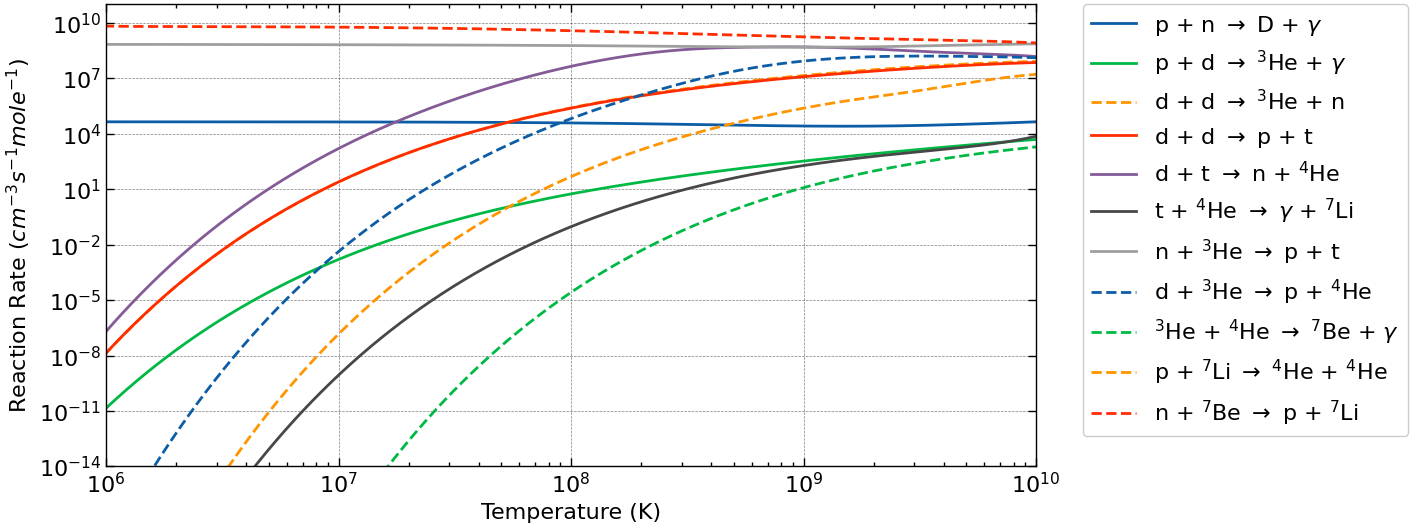

In [ ]:
#plotting reaction rate vs temperature for reactions in the BBN network
plt.figure(figsize=(12, 6))
plt.plot(T9*1e9, pn_dg, label=r'p + n $\rightarrow$ D + $\gamma$')
plt.plot(T9*1e9, pd_3he, label=r'p + d $\rightarrow$ $^3$He + $\gamma$')
plt.plot(T9*1e9, dd_n3he, '--', label=r'd + d $\rightarrow$ $^3$He + n')
plt.plot(T9*1e9, dd_pt, label=r'd + d $\rightarrow$ p + t')
plt.plot(T9*1e9, dt_n4he, label=r'd + t $\rightarrow$ n + $^4$He')
plt.plot(T9*1e9, t4he_Li, label=r't + $^4$He $\rightarrow$ $\gamma$ + $^7$Li')
plt.plot(T9*1e9, n3he_pt, label=r'n + $^3$He $\rightarrow$ p + t')
plt.plot(T9*1e9, d3he_p4he, '--', label=r'd + $^3$He $\rightarrow$ p + $^4$He')
plt.plot(T9*1e9, He43He_7be, '--', label=r'$^3$He + $^4$He $\rightarrow$ $^7$Be + $\gamma$')
plt.plot(T9*1e9, p7Li_4He4He, '--', label=r'p + $^7$Li $\rightarrow$ $^4$He + $^4$He')
plt.plot(T9*1e9, n7Be_p7Li, '--', label=r'n + $^7$Be $\rightarrow$ p + $^7$Li')



plt.xlabel('Temperature (K)')
plt.ylabel(r'Reaction Rate $(cm^{-3} s^{-1} mole^{-1})$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(left = 10**6, right = 10**10) #the reaclib databse is optimized for these temperatures
plt.ylim(top = 10**11, bottom= 10**(-14))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [ ]:
#defining expressions to be used in the differential equations.

g_star = 9
eta_b = 6.12e-10  #baryon to photon ratio

# n/p
Q = mn - mp

def T_fout(v):
    return 0.8 * (v / 246)**(4/3)


T_freeze = T_fout(v_value)    
t_fout = 2.4 / (np.sqrt(g_star) * T_freeze**2) 

T_bottleneck = 0.07



np_ratio = np.where(Tm > T_freeze,
                    np.exp(-Q/Tm),
                    (1/7) * np.exp(-(t-t_fout)* decay_rate)) #t_fout is the time when Temp = T_freeze, when the freeze out happens. 
Yn = np_ratio / (1 + np_ratio)
Yp = 1.0 / (1 + np_ratio)



# binding energies in MeV
B = {'d': 2.224, 't': 8.482, '3He': 7.718, '4He': 28.296, '7Li': 39.244, '7Be': 37.600}
g_i = {'d': 3, 't': 2, '3He': 2, '4He': 1, '7Li': 4, '7Be': 4}
A_i = {'d': 2, 't': 3, '3He': 3, '4He': 4, '7Li': 7, '7Be': 7}

def Y_nuc(A, Bi, gi, Tm):
    # compute exponent first to check for overflow
    exponent = Bi / Tm + (3*(A-1)/2) * np.log(Tm/mn) + (A-1)*np.log(eta_b) + np.log(gi)   #eq. 23 from BBN-simple
    exponent = np.clip(exponent, -700, 700)
    result = np.exp(exponent)
    return np.where(np.isfinite(result) & (result < 1.0), result, 0.0)


Yd   = Y_nuc(2, 2.224,  3, Tm)  #deuterium number density fraction
Yt   = Y_nuc(3, 8.482,  2, Tm)
Y3He = Y_nuc(3, 7.718,  2, Tm)
Y4He = Y_nuc(4, 28.296, 1, Tm)
Y7Li = Y_nuc(7, 39.244, 4, Tm)
Y7Be = Y_nuc(7, 37.600, 4, Tm)


In [8]:
#defining the rates as funtions of temperature

# n --> p : weak interaction
def n_p(Tm):
    z = 0.511 / Tm
    return (1 + 0.565/z - 6.382/z**2 + 11.108/z**3 + 36.492/z**4 + 27.512/z**5) * (1* decay_rate)

def n_pR(Tm):
    z = 0.511 / Tm
    return (5.252/z - 16.229/z**2 + 18.059/z**3 + 34.181/z**4 + 27.617/z**5) * (1* decay_rate) * np.exp(-(mn - mp)/(0.511) * z)

# p + n --> D + \gamma
def pn_dg(T9):
    exponent_1 = (1.075480e+01) + 0/T9 + 0/(T9**(1/3)) + (-2.304720e+00)*(T9**(1/3)) + (-8.878620e-01)*T9 + (1.376630e-01)*(T9**(5/3)) + 0*np.log(T9)
    pn_dg_1 = np.exp(exponent_1) 
    pn_dg_2 = np.exp( (1.236870e+01) + (0)/T9 + 0/(T9**(1/3)) + (-2.706180e+00)*(T9**(1/3)) + (1.171800e-01)*T9 + (-3.127880e-03)*(T9**(5/3)) + (4.691270e-01)*np.log(T9) )
    pn_dg_3 = np.exp( (8.846880e+00) + (0)/T9 + 0/(T9**(1/3)) + (-1.020820e-02)*(T9**(1/3)) + (-8.939590e-02)*T9 + (6.967040e-03)*(T9**(5/3)) + (1.000000e+00)*np.log(T9) )
    return pn_dg_1 + pn_dg_2 + pn_dg_3 

# (reverse reaction)
def pn_dgR(T9):
    pn_dg_1R = np.exp( (3.110750e+01) + (-2.581500e+01)/T9 + 0/(T9**(1/3)) + (-1.020820e-02)*(T9**(1/3)) + (-8.939590e-02)*T9 + (6.967040e-03)*(T9**(5/3)) + (2.500000e+00)*np.log(T9) )
    pn_dg_2R = np.exp( (3.462930e+01) + (-2.581500e+01)/T9 + 0/(T9**(1/3)) + (-2.706180e+00)*(T9**(1/3)) + (1.171800e-01)*T9 + (-3.127880e-03)*(T9**(5/3)) + (1.969130e+00)*np.log(T9) )
    pn_dg_3R = np.exp( (3.301540e+01) + (-2.581500e+01)/T9 + 0/(T9**(1/3)) + (-2.304720e+00)*(T9**(1/3)) + (-8.878620e-01)*T9 + (1.376630e-01)*(T9**(5/3)) + (1.500000e+00)*np.log(T9) )
    return pn_dg_1R + pn_dg_2R + pn_dg_3R

# p + d --> 3He
def pd_3he(T9):
    pd_3he_1 = np.exp( (7.528980e+00) + (0.000000e+00)/T9 + (-3.720800e+00)/(T9**(1/3)) + (8.717820e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    pd_3he_2 = np.exp( (8.935250e+00) + (0.000000e+00)/T9 + (-3.720800e+00)/(T9**(1/3)) + (1.986540e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (3.333330e-01)*np.log(T9) )
    return pd_3he_1 + pd_3he_2

# reverse
def pd_3heR(T9):
    pd_3he_1R = np.exp( (3.103200e+01) + (-6.374350e+01)/T9 + (-3.720800e+00)/(T9**(1/3)) + (8.717820e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (8.333330e-01)*np.log(T9) )
    pd_3he_2R = np.exp( (3.243830e+01) + (-6.374350e+01)/T9 + (-3.720800e+00)/(T9**(1/3)) + (1.986540e-01)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (1.833330e+00)*np.log(T9) )
    return pd_3he_1R + pd_3he_2R

# d + d --> n + 3he
def dd_n3he(T9):
    return np.exp( (1.908760e+01) + (-1.900200e-04)/T9 + (-4.229200e+00)/(T9**(1/3)) + (1.693200e+00)*(T9**(1/3)) + (-8.555290e-02)*T9 + (-1.357090e-25)*(T9**(5/3)) + (-7.345130e-01)*np.log(T9) )

# reverse
def dd_n3heR(T9):
    return np.exp( (1.963690e+01) + (-3.793580e+01)/T9 + (-4.229200e+00)/(T9**(1/3)) + (1.693200e+00)*(T9**(1/3)) + (-8.555290e-02)*T9 + (-1.357090e-25)*(T9**(5/3)) + (-7.345130e-01)*np.log(T9) )

# d + d --> p + t
def dd_pt(T9):
    return np.exp( (1.880520e+01) + (4.362090e-05)/T9 + (-4.322960e+00)/(T9**(1/3)) + (1.915720e+00)*(T9**(1/3)) + (-8.156200e-02)*T9 + (-3.288040e-22)*(T9**(5/3)) + (-8.795180e-01)*np.log(T9) )

# reverse
def dd_ptR(T9):
    return np.exp( (1.935450e+01) + (-4.679900e+01)/T9 + (-4.322960e+00)/(T9**(1/3)) + (1.915720e+00)*(T9**(1/3)) + (-8.156200e-02)*T9 + (-3.288040e-22)*(T9**(5/3)) + (-8.795180e-01)*np.log(T9) )

# d + t --> n + 4he
def dt_n4he(T9):
    dt_n4he_1 = np.exp( (2.517940e+01) + (0.000000e+00)/T9 + (-4.524400e+00)/(T9**(1/3)) + (3.503370e-01)*(T9**(1/3)) + (5.874700e-01)*T9 + (-8.849090e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    dt_n4he_2 = np.exp( (3.934570e+01) + (0.000000e+00)/T9 + (-4.524400e+00)/(T9**(1/3)) + (-1.640280e+01)*(T9**(1/3)) + (1.731030e+00)*T9 + (-1.229660e-01)*(T9**(5/3)) + (2.313040e+00)*np.log(T9) )
    return dt_n4he_1 + dt_n4he_2  

# reverse
def dt_n4heR(T9):
    dt_n4he_1R = np.exp( (2.688620e+01) + (-2.041120e+02)/T9 + (-4.524400e+00)/(T9**(1/3)) + (3.503370e-01)*(T9**(1/3)) + (5.874700e-01)*T9 + (-8.849090e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    dt_n4he_2R = np.exp( (4.105250e+01) + (-2.041120e+02)/T9 + (-4.524400e+00)/(T9**(1/3)) + (-1.640280e+01)*(T9**(1/3)) + (1.731030e+00)*T9 + (-1.229660e-01)*(T9**(5/3)) + (2.313040e+00)*np.log(T9) )
    return dt_n4he_1R + dt_n4he_2R

# t + 4He --> 7Li + \gamma
def t4he_Li(T9):
    return np.exp( (1.361620e+01) + (0.000000e+00)/T9 + (-8.080500e+00)/(T9**(1/3)) + (-2.175140e-01)*(T9**(1/3)) + (-1.148590e-01)*T9 + (4.700430e-02)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )

# reverse
def t4he_LiR(T9):
    return np.exp( (3.674420e+01) + (-2.862830e+01)/T9 + (-8.080500e+00)/(T9**(1/3)) + (-2.175140e-01)*(T9**(1/3)) + (-1.148590e-01)*T9 + (4.700430e-02)*(T9**(5/3)) + (8.333330e-01)*np.log(T9) )

# n + 3He --> p + t
def n3he_pt(T9):
    n3he_pt_1 = np.exp( (2.037870e+01) + (0.000000e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (-3.327880e-01)*(T9**(1/3)) + (-7.004850e-01)*T9 + (9.765210e-02)*(T9**(5/3)) + (0.000000e+00)*np.log(T9) )
    n3he_pt_2 = np.exp( (1.927620e+01) + (0.000000e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (4.385570e-02)*(T9**(1/3)) + (-2.015270e-01)*T9 + (1.534330e-02)*(T9**(5/3)) + (1.000000e+00)*np.log(T9) )
    return n3he_pt_1 + n3he_pt_2

# reverse
def n3he_ptR(T9):
    n3he_pt_1R = np.exp( (2.037870e+01) + (-8.863520e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (-3.327880e-01)*(T9**(1/3)) + (-7.004850e-01)*T9 + (9.765210e-02)*(T9**(5/3)) + (0.000000e+00)*np.log(T9) )
    n3he_pt_2R = np.exp( (1.927620e+01) + (-8.863520e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (4.385570e-02)*(T9**(1/3)) + (-2.015270e-01)*T9 + (1.534330e-02)*(T9**(5/3)) + (1.000000e+00)*np.log(T9) )
    return n3he_pt_1R + n3he_pt_2R

# d + 3He --> p + 4He
def d3he_p4he(T9):
    d3he_p4he_1 = np.exp( (2.468390e+01) + (0.000000e+00)/T9 + (-7.182000e+00)/(T9**(1/3)) + (4.732880e-01)*(T9**(1/3)) + (1.468470e+00)*T9 + (-2.796030e+01)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    d3he_p4he_2 = np.exp( (4.129690e+01) + (0.000000e+00)/T9 + (-7.182000e+00)/(T9**(1/3)) + (-1.713490e+01)*(T9**(1/3)) + (1.369080e+00)*T9 + (-8.144230e-02)*(T9**(5/3)) + (3.353950e+00)*np.log(T9) )
    return d3he_p4he_1 + d3he_p4he_2

# reverse
def d3he_p4heR(T9):
    d3he_p4he_1R = np.exp( (2.639070e+01) + (-2.129770e+02)/T9 + (-7.182000e+00)/(T9**(1/3)) + (4.732880e-01)*(T9**(1/3)) + (1.468470e+00)*T9 + (-2.796030e+01)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    d3he_p4he_2R = np.exp( (4.300370e+01) + (-2.129770e+02)/T9 + (-7.182000e+00)/(T9**(1/3)) + (-1.713490e+01)*(T9**(1/3)) + (1.369080e+00)*T9 + (-8.144230e-02)*(T9**(5/3)) + (3.353950e+00)*np.log(T9) )
    return d3he_p4he_1R + d3he_p4he_2R

# 4He + 3He --> 7Be
def He43He_7be(T9):
    He43He_7be_1 = np.exp( (1.560990e+01) + (0.000000e+00)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.082250e-02)*(T9**(1/3)) + (-6.546850e-01)*T9 + (8.963310e-02)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    He43He_7be_2 = np.exp( (1.770750e+01) + (0.000000e+00)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.812600e+00)*(T9**(1/3)) + (9.422850e-02)*T9 + (-3.010180e-03)*(T9**(5/3)) + (1.333330e+00)*np.log(T9) )
    return He43He_7be_1 + He43He_7be_2

# reverse
def He43He_7beR(T9):
    He43He_7be_1R = np.exp( (3.873790e+01) + (-1.840590e+01)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.082250e-02)*(T9**(1/3)) + (-6.546850e-01)*T9 + (8.963310e-02)*(T9**(5/3)) + (8.333330e-01)*np.log(T9) )
    He43He_7be_2R = np.exp( (4.083550e+01) + (-1.840590e+01)/T9 + (-1.282710e+01)/(T9**(1/3)) + (-3.812600e+00)*(T9**(1/3)) + (9.422850e-02)*T9 + (-3.010180e-03)*(T9**(5/3)) + (2.833330e+00)*np.log(T9) )
    return He43He_7be_1R + He43He_7be_2R

# p + 7Li --> 4He + 4He
def p7Li_4He4He(T9):
    p7Li_4He4He_1 = np.exp( (2.044380e+01) + (0.000000e+00)/T9 + (-8.472700e+00)/(T9**(1/3)) + (2.979340e-01)*(T9**(1/3)) + (5.823350e-02)*T9 + (-4.133830e-03)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    p7Li_4He4He_2 = np.exp( (2.189990e+01) + (-2.615270e+01)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )
    p7Li_4He4He_3 = np.exp( (1.195760e+01) + (0.000000e+00)/T9 + (-8.472700e+00)/(T9**(1/3)) + (4.179430e-01)*(T9**(1/3)) + (5.345650e+00)*T9 + (-4.868400e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    p7Li_4He4He_4 = np.exp( (1.425380e+01) + (-4.478000e+00)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )
    return p7Li_4He4He_1 + p7Li_4He4He_2 + p7Li_4He4He_3 + p7Li_4He4He_4

# reverse
def p7Li_4He4HeR(T9):
    p7Li_4He4He_1R = np.exp( (1.349020e+01) + (-2.013120e+02)/T9 + (-8.472700e+00)/(T9**(1/3)) + (4.179430e-01)*(T9**(1/3)) + (5.345650e+00)*T9 + (-4.868400e+00)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    p7Li_4He4He_2R = np.exp( (1.578640e+01) + (-2.057900e+02)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )
    p7Li_4He4He_3R = np.exp( (2.197640e+01) + (-2.013120e+02)/T9 + (-8.472700e+00)/(T9**(1/3)) + (2.979340e-01)*(T9**(1/3)) + (5.823350e-02)*T9 + (-4.133830e-03)*(T9**(5/3)) + (-6.666670e-01)*np.log(T9) )
    p7Li_4He4He_4R = np.exp( (2.343250e+01) + (-2.274650e+02)/T9 + (0.000000e+00)/(T9**(1/3)) + (0.000000e+00)*(T9**(1/3)) + (0.000000e+00)*T9 + (0.000000e+00)*(T9**(5/3)) + (-1.500000e+00)*np.log(T9) )
    return p7Li_4He4He_1R + p7Li_4He4He_2R + p7Li_4He4He_3R + p7Li_4He4He_4R

# n + 7Be --> p + 7Li
def n7Be_p7Li(T9):
    return np.exp( (2.178990e+01) + (7.280980e-04)/T9 + (-3.025400e-01)/(T9**(1/3)) + (-3.602000e-01)*(T9**(1/3)) + (1.747200e-01)*T9 + (-2.230000e-02)*(T9**(5/3)) + (-4.581000e-01)*np.log(T9) )

# reverse
def n7Be_p7LiR(T9):
    return np.exp( (2.178990e+01) + (-1.907790e+01)/T9 + (-3.025400e-01)/(T9**(1/3)) + (-3.602000e-01)*(T9**(1/3)) + (1.747200e-01)*T9 + (-2.230000e-02)*(T9**(5/3)) + (-4.581000e-01)*np.log(T9) )

In [ ]:
from scipy.integrate import solve_ivp


def bbn_odes(t_val, Y):
      Yn, Yp, Yd, Yt, Y3He, Y4He, Y7Li, Y7Be = Y

      # temperature at this time
      Tm_val = np.sqrt(2.42 * 9**(-0.5) * t_val**(-1))  # MeV
      T9_val = Tm_val / 0.08617   
    

      hbar_c = 1.973e-11            #  1.973e-11          # MeV*cm
      n_gamma = (2 * 1.202 / np.pi**2) * (Tm_val / hbar_c)**3  # cm^-3, photon density
      Nb_val = eta_b * n_gamma
      rho_b = Nb_val / 6.022e23   # rhob = Nb/N_A, baryon density

      #ODEs
      dYndt = -Yn* decay_rate + Yp * n_pR(Tm_val)  - Yn*n_p(Tm_val) \
                  + Yd*Yd/2 * dd_n3he(T9_val) * rho_b - Yn*Y3He*dd_n3heR(T9_val) * rho_b - Yn*Yp*pn_dg(T9_val)* rho_b \
                  + Yd*pn_dgR(T9_val) + Yd*Yt*dt_n4he(T9_val) * rho_b - Yn*Y4He*dt_n4heR(T9_val)* rho_b \
                  -Y3He*Yn*n3he_pt(T9_val)* rho_b + Yp*Yt*n3he_ptR(T9_val) * rho_b \
                  - Yn*Y7Be*n7Be_p7Li(T9_val) * rho_b + Yp*Y7Li*n7Be_p7LiR(T9_val) * rho_b
      
      dYpdt = Yn* decay_rate  - Yp * n_pR(Tm_val) + Yn*n_p(Tm_val) \
                  - Yp*Yn*pn_dg(T9_val) * rho_b + Yd*pn_dgR(T9_val) \
                  - Yd*Yp*pd_3he(T9_val) * rho_b + Y3He*pd_3heR(T9_val) \
                  + Yd*Yd/2 * dd_pt(T9_val) * rho_b - Yp*Yt*dd_ptR(T9_val) * rho_b \
                  + Y3He*Yn*n3he_pt(T9_val) * rho_b - Yp*Yt*n3he_ptR(T9_val) * rho_b \
                  + Y3He*Yd*d3he_p4he(T9_val) * rho_b - Yp*Y4He*d3he_p4heR(T9_val) * rho_b \
                  - Yp*Y7Li*p7Li_4He4He(T9_val) * rho_b + (Y4He*Y4He*p7Li_4He4HeR(T9_val)/2) * rho_b \
                  + Y7Be*Yn* n7Be_p7Li(T9_val) * rho_b - Yp*Y7Li*n7Be_p7LiR(T9_val) * rho_b


      dYddt = -Yd*pn_dgR(T9_val) + Yn*Yp*pn_dg(T9_val) * rho_b\
                  - Yd*Yp*pd_3he(T9_val) * rho_b + Y3He*pd_3heR(T9_val) \
                  - (Yd*Yd*dd_n3he(T9_val)/2)*2 * rho_b + Yn*Y3He*dd_n3heR(T9_val)*2 * rho_b \
                  - (Yd*Yd*dd_pt(T9_val)/2)*2 * rho_b + Yt*Yp*dd_ptR(T9_val)*2 * rho_b \
                  - Yd*Yt*dt_n4he(T9_val) * rho_b + Yn*Y4He*dt_n4heR(T9_val)* rho_b \
                  - Yd*Y3He*d3he_p4he(T9_val)* rho_b + Yp*Y4He*d3he_p4heR(T9_val) * rho_b #rate of change 

      dY3Hedt = Yd*Yp*pd_3he(T9_val)* rho_b - Y3He*pd_3heR(T9_val) \
            + (Yd*Yd*dd_n3he(T9_val)/2)* rho_b - Yn*Y3He*dd_n3heR(T9_val) * rho_b\
            - Yn*Y3He*n3he_pt(T9_val)* rho_b + Yp*Yt*n3he_ptR(T9_val)* rho_b \
            - Yd*Y3He*d3he_p4he(T9_val)* rho_b + Yp*Y4He*d3he_p4heR(T9_val) * rho_b\
            - Y3He*Y4He*He43He_7be(T9_val) * rho_b + Y7Be*He43He_7beR(T9_val)
      
      dYtdt = (Yd*Yd*dd_pt(T9_val)/2) * rho_b - Yp*Yt*dd_ptR(T9_val)* rho_b \
            + Yn*Y3He*n3he_pt(T9_val)* rho_b - Yp*Yt*n3he_ptR(T9_val)* rho_b \
            - Yd*Yt*dt_n4he(T9_val)* rho_b + Yn*Y4He*dt_n4heR(T9_val)* rho_b \
            - Yt*Y4He*t4he_Li(T9_val)* rho_b + Y7Li*t4he_LiR(T9_val)
    
      dY4Hedt = Yd*Yt*dt_n4he(T9_val) * rho_b - Yn*Y4He*dt_n4heR(T9_val)* rho_b \
            + Yd*Y3He*d3he_p4he(T9_val)* rho_b - Yp*Y4He*d3he_p4heR(T9_val)* rho_b \
            + (Y7Li*Yp*p7Li_4He4He(T9_val))*2 * rho_b - (Y4He*Y4He*p7Li_4He4HeR(T9_val)/2)*2 * rho_b \
            + Y7Li*t4he_LiR(T9_val) - Yt*Y4He*t4he_Li(T9_val) * rho_b \
            + Y7Be*He43He_7beR(T9_val) - Y3He*Y4He*He43He_7be(T9_val) * rho_b
      
      dY7Lidt = Yt*Y4He*t4he_Li(T9_val) * rho_b - Y7Li*t4he_LiR(T9_val) \
            + Yn*Y7Be*n7Be_p7Li(T9_val)* rho_b - Yp*Y7Li*n7Be_p7LiR(T9_val) * rho_b \
            - Yp*Y7Li*p7Li_4He4He(T9_val)* rho_b + (Y4He*Y4He*p7Li_4He4HeR(T9_val)/2) * rho_b 
      
      dY7Bedt = Y3He*Y4He*He43He_7be(T9_val) * rho_b - Y7Be*He43He_7beR(T9_val) \
            - Yn*Y7Be*n7Be_p7Li(T9_val) * rho_b + Yp*Y7Li*n7Be_p7LiR(T9_val) * rho_b
      


    return [dYndt, dYpdt, dYddt, dYtdt, dY3Hedt, dY4Hedt, dY7Lidt, dY7Bedt]



In [10]:
#initial conditions

T_start = max(1.0, T_freeze)     # ODE integration starting temperauture in MeV, we must always start from T > 1 MeV to ensure the Saha equation is valid 

t_start = 2.42 * g_star**(-0.5) / T_start**2  


# n/p ratio in equilibrium at T_start
np_ratio_init = np.exp(-Q / T_start)
Yn0 = np_ratio_init / (1 + np_ratio_init)
Yp0 = 1.0 / (1 + np_ratio_init)




# all nuclei negligible at T_start; the Saha equation is only valid when T > 1 MeV !!!
Y0 = [Yn0, Yp0, Y_nuc(2, 2.224,  3, T_start), Y_nuc(3, 8.482,  2, T_start), Y_nuc(3, 7.718,  2, T_start), Y_nuc(4, 28.296, 1, T_start), Y_nuc(7, 39.244, 4, T_start), Y_nuc(7, 37.600, 4, T_start)]

In [11]:
#ODE Solver

import time
from tqdm import tqdm

# Time Tracking & Progress Setup
# Initialize the tqdm manual progress bar tracking the integration t_span
pbar = tqdm(total=100, desc="Solving ODEs", unit="%")
last_t = t_start

t_end = 10000
def bbn_odes_wrapper(t, y):
    global last_t
    
    # Update progress bar based on percentage completion of the time span
    if t > last_t:  # Only advance bar if the solver is moving forward in time
        percentage_moved = ((t - last_t) / (t_end - t_start)) * 100
        pbar.update(percentage_moved)
        last_t = t
        
    return bbn_odes(t, y)

# Start execution timer
start_wall_time = time.perf_counter()

# Solving the ODEs
sol = solve_ivp(
    fun=bbn_odes_wrapper,  # Call our progress-tracking wrapper function      
    t_span=(t_start, t_end),  
    y0=Y0,               
    method='Radau',      #Radau method is suitable for stiff ODEs
    rtol=1e-6,           
    atol= 1e-15,          
    dense_output=True    
)

# Ensure the progress bar explicitly finishes at 100% and closes properly
pbar.n = 100
pbar.refresh()
pbar.close()

# Stop execution timer
end_wall_time = time.perf_counter()
execution_time = end_wall_time - start_wall_time

# Summary Output
print("\n" + "="*40)
print(f"Solver Success : {sol.success}")
print(f"Solver Message : {sol.message}")
print(f"Total Step Count: {len(sol.t)} internal integration steps taken")
print(f"Execution Time : {execution_time:.4f} seconds")
print("="*40 + "\n")

#Extracting Results 
t_sol = sol.t
Yn_sol   = sol.y[0]
Yp_sol   = sol.y[1]
Yd_sol   = sol.y[2]
Yt_sol   = sol.y[3]
Y3He_sol = sol.y[4]
Y4He_sol = sol.y[5]
Y7Li_sol = sol.y[6]
Y7Be_sol = sol.y[7]




Solving ODEs:   0%|          | 0.0011588829143768537/100 [00:00<2:24:35, 86.76s/%]

Solving ODEs: 100%|██████████| 100/100 [00:04<00:00, 22.33%/s]                    


Solver Success : True
Solver Message : The solver successfully reached the end of the integration interval.
Total Step Count: 453 internal integration steps taken
Execution Time : 4.4789 seconds



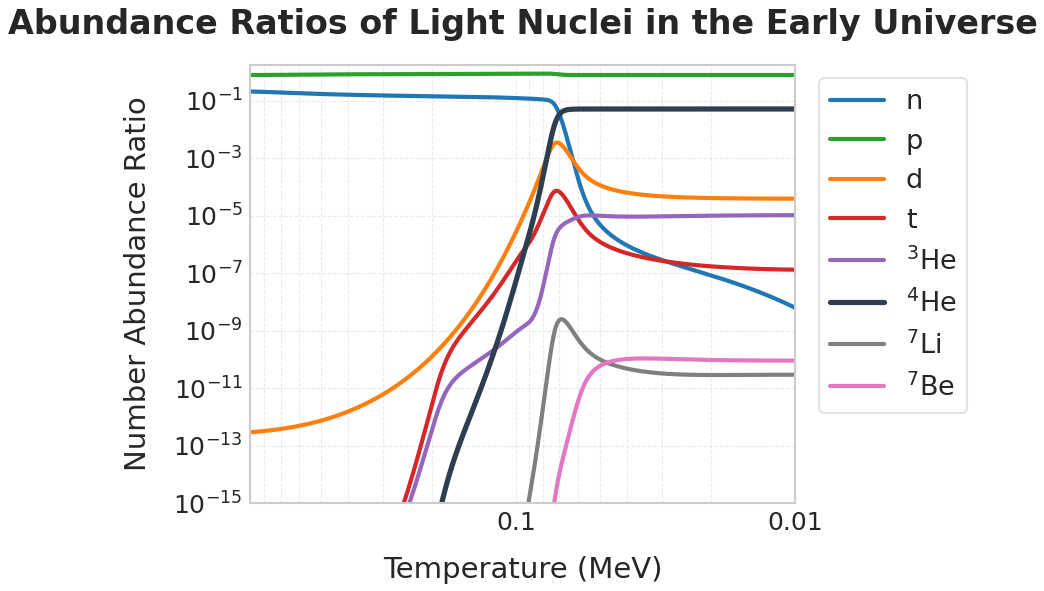

In [12]:
#Number Abundance plotting

t_plot = np.logspace(np.log10(t_start), np.log10(t_end), 3000)
Y_plot = sol.sol(t_plot)


Yn_plot   = Y_plot[0]
Yp_plot   = Y_plot[1]
Yd_plot   = Y_plot[2]
Yt_plot   = Y_plot[3]
Y3He_plot = Y_plot[4]
Y4He_plot = Y_plot[5]
Y7Li_plot = Y_plot[6]
Y7Be_plot = Y_plot[7]

Tm_plot = np.sqrt(2.42 * g_star**(-0.5) * t_plot**(-1)) #x axis in MeV



# making plots prettier
import matplotlib.ticker as ticker


plt.style.use('seaborn-v0_8-whitegrid') # Gives a clean background grid


plt.figure(figsize=(6, 4.2), dpi=150) 


plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13
})


colors = {
    'n': '#1f77b4',    
    'p': '#2ca02c',    
    'd': '#ff7f0e',     
    't': '#d62728',     
    '3He': '#9467bd',    
    '4He': '#2c3e50',    
    '7Li': '#7f7f7f',    
    '7Be': '#e377c2'     
}


plt.plot(Tm_plot, Yn_plot, label='n', color=colors['n'], linewidth=2)
plt.plot(Tm_plot, Yp_plot, label='p', color=colors['p'], linewidth=2)
plt.plot(Tm_plot, Yd_plot, label='d', color=colors['d'], linewidth=2)
plt.plot(Tm_plot, Yt_plot, label='t', color=colors['t'], linewidth=2)
plt.plot(Tm_plot, Y3He_plot, label=r'$^3$He', color=colors['3He'], linewidth=2)
plt.plot(Tm_plot, Y4He_plot, label=r'$^4$He', color=colors['4He'], linewidth=2.5) # Thicker line for major component
plt.plot(Tm_plot, Y7Li_plot, label=r'$^7$Li', color=colors['7Li'], linewidth=2)
plt.plot(Tm_plot, Y7Be_plot, label=r'$^7$Be', color=colors['7Be'], linewidth=2)



plt.title('Abundance Ratios of Light Nuclei in the Early Universe', pad=15, fontweight='bold')
plt.xlabel('Temperature (MeV)', labelpad=10)
plt.ylabel('Number Abundance Ratio', labelpad=10)

# Scale, Limits, and Tick Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.9, 0.01)
plt.ylim(10**(-15), 1.8)  #NOTE: do not decrease the lower limit, as the processor may not be capable of handling such small precision.

plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))


plt.grid(True, which="both", ls="--", color='#e2e2e2', alpha=0.7)


plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='#e2e2e2')


plt.tight_layout()


plt.show()





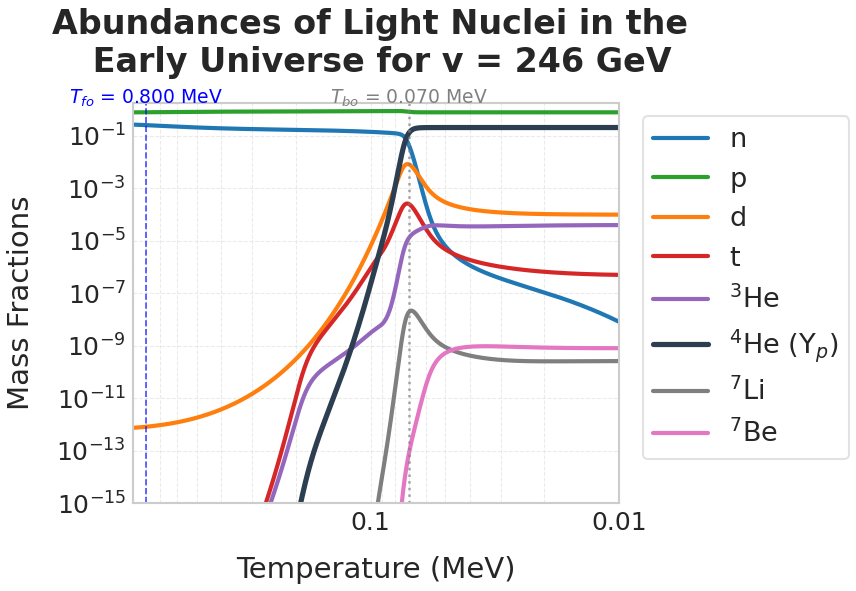

In [13]:
#Xi - mass fraction of species i - reported wrt Xp as is convention in BBN literature

Xp = Ap * Yp_plot
Xn = An * Yn_plot/Xp
Xd = Ad * Yd_plot/Xp
Xt = At * Yt_plot/Xp
X3He = A3He * Y3He_plot/Xp
X4He = A4He * Y4He_plot
X7Li = A7Li * Y7Li_plot / Xp
X7Be = A7Be * Y7Be_plot / Xp


plt.style.use('seaborn-v0_8-whitegrid') # Gives a background grid


plt.figure(figsize=(6, 4.2), dpi=150) # High DPI for crisp lines


plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13
})


colors = {
    'n': '#1f77b4',     
    'p': '#2ca02c',     
    'd': '#ff7f0e',     
    't': '#d62728',     
    '3He': '#9467bd',    
    '4He': '#2c3e50',    
    '7Li': '#7f7f7f',    
    '7Be': '#e377c2' 
}


plt.plot(Tm_plot, Xn, label='n', color=colors['n'], linewidth=2)
plt.plot(Tm_plot, Xp, label='p', color=colors['p'], linewidth=2)
plt.plot(Tm_plot, Xd, label='d', color=colors['d'], linewidth=2)
plt.plot(Tm_plot, Xt, label='t', color=colors['t'], linewidth=2)
plt.plot(Tm_plot, X3He, label=r'$^3$He', color=colors['3He'], linewidth=2)
plt.plot(Tm_plot, X4He, label=r'$^4$He (Y$_p$)', color=colors['4He'], linewidth=2.5) # Thicker line for major component
plt.plot(Tm_plot, X7Li, label=r'$^7$Li', color=colors['7Li'], linewidth=2)
plt.plot(Tm_plot, X7Be, label=r'$^7$Be', color=colors['7Be'], linewidth=2)



plt.title(f'Abundances of Light Nuclei in the \n Early Universe for v = {v_value} GeV', pad=15, fontweight='bold')
plt.xlabel('Temperature (MeV)', labelpad=10)
plt.ylabel('Mass Fractions', labelpad=10)

# Scale, Limits, and Tick Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.9, 0.01)
plt.ylim(10**(-15), 1.8)
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))


plt.grid(True, which="both", ls="--", color='#e2e2e2', alpha=0.7)


plt.axvline(x=T_freeze, color='blue', linestyle='--', linewidth=0.8, alpha=0.7)
plt.text(T_freeze, 1.1, fr'$T_{{fo}}$ = {T_freeze:.3f} MeV', rotation=0, va='bottom', ha='center',
          fontsize=9, color='blue')

plt.axvline(x=T_bottleneck, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
plt.text(T_bottleneck, 1.1, fr'$T_{{bo}}$ = {T_bottleneck:.3f} MeV', rotation=0, va='bottom', ha='center',
          fontsize=9, color='gray')


plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='#e2e2e2')


plt.tight_layout()


plt.show()

Text(0, 0.5, 'Y$_4$')

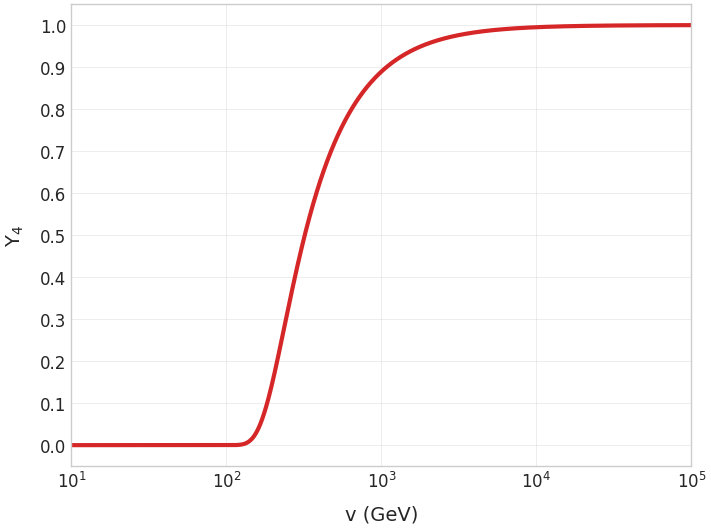

In [14]:
# Y4 versus v plot

v0 = 246.0

v= np.logspace(1, 5, 3000)

T_fo = 0.9 * (v/v0)**(4/3)                     # MeV, Mpl fixed
t_fo = 2.4 / np.sqrt(g_star) / T_fo**2         # seconds
t_bottleneck = 2.4 / np.sqrt(g_star) / (0.06)**2

decay_rate_1 = (1/880) * (v0/v)**4               # <-- fixed direction

dt = np.maximum(t_bottleneck - t_fo, 0)
decay_factor = np.exp(-decay_rate_1 * dt) #for low values of v, t_bottleneck < t_fo, so we set dt = 0 to avoid unphysical growth of n/p ratio. 
#Basically, at small v, the freeze out is predicted to happen AFTER the bottleneck is reached, which is unphysical. 


nbyp = np.exp(-(mn - mp)/T_fo) * decay_factor
Y4 = 2*nbyp / (1 + nbyp)

plt.plot(v, Y4, color='#d62728', lw=3)
plt.xscale('log')


plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.1))

plt.xlim(10, 100000)
# plt.ylim(-0.1, 1.1)
plt.xlabel('v (GeV)', labelpad=10)
plt.ylabel(r'Y$_4$', labelpad=10)